<a href="https://colab.research.google.com/github/DannyJung23/SatelliteDataAI-UoA/blob/main/My-Lab-Notebooks/761_Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Cloud Clearing in Sentinel-2: Combining Spectral and Clustering Approaches

### Set up

In [4]:
!pip install geemap --quiet

In [5]:
import ee
ee.Authenticate()
ee.Initialize(project='uoa-gisci')

In [115]:
import geemap
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import seaborn as sns
import urllib.request
import tempfile
import os

from sklearn.cluster import KMeans

### Define AoI and cloud mask parameters

In [18]:
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 60
CLD_PRB_THRESH = 50
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 50

### Build Sentinel-2 ImageCollection

In [19]:
def get_s2_sr_cld_col(aoi, start_date, end_date):
    # Import and filter S2 SR.
    s2_sr_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', CLOUD_FILTER)))

    # Import and filter s2cloudless.
    s2_cloudless_col = (ee.ImageCollection('COPERNICUS/S2_CLOUD_PROBABILITY')
        .filterBounds(aoi)
        .filterDate(start_date, end_date))

    # Join the filtered s2cloudless collection to the SR collection by the 'system:index' property.
    return ee.ImageCollection(ee.Join.saveFirst('s2cloudless').apply(**{
        'primary': s2_sr_col,
        'secondary': s2_cloudless_col,
        'condition': ee.Filter.equals(**{
            'leftField': 'system:index',
            'rightField': 'system:index'
        })
    }))

In [20]:
# Apply the function in order to generate the collection
s2_sr_cld_col_eval = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

In [21]:
Map = geemap.Map(basemap="HYBRID")
Map.centerObject(AOI, 10)
Map.addLayer(s2_sr_cld_col_eval, {'bands':['B4','B3','B2'], 'min':0, 'max':3000}, 'S2 collection (before)')
Map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

### Define cloud mask component functions

Detects cloud pixels by thresholding s2cloudless cloud probability.

In [22]:
def add_cloud_bands(img):
    # Get s2cloudless image, subset the probability band.
    cld_prb = ee.Image(img.get('s2cloudless')).select('probability')

    # Condition s2cloudless by the probability threshold value.
    is_cloud = cld_prb.gt(CLD_PRB_THRESH).rename('clouds')

    # Add the cloud probability layer and cloud mask as image bands.
    return img.addBands(ee.Image([cld_prb, is_cloud]))

Detects cloud shadows using dark NIR pixels, non-water masking, and cloud projection.

In [23]:
def add_shadow_bands(img):
    # Identify water pixels from the SCL band.
    not_water = img.select('SCL').neq(6)

    # Identify dark NIR pixels that are not water (potential cloud shadow pixels).
    SR_BAND_SCALE = 1e4
    dark_pixels = img.select('B8').lt(NIR_DRK_THRESH*SR_BAND_SCALE).multiply(not_water).rename('dark_pixels')

    # Determine the direction to project cloud shadow from clouds (assumes UTM projection).
    shadow_azimuth = ee.Number(90).subtract(ee.Number(img.get('MEAN_SOLAR_AZIMUTH_ANGLE')));

    # Project shadows from clouds for the distance specified by the CLD_PRJ_DIST input.
    cld_proj = (img.select('clouds').directionalDistanceTransform(shadow_azimuth, CLD_PRJ_DIST*10)
        .reproject(**{'crs': img.select(0).projection(), 'scale': 100})
        .select('distance')
        .mask()
        .rename('cloud_transform'))

    # Identify the intersection of dark pixels with cloud shadow projection.
    shadows = cld_proj.multiply(dark_pixels).rename('shadows')

    # Add dark pixels, cloud projection, and identified shadows as image bands.
    return img.addBands(ee.Image([dark_pixels, cld_proj, shadows]))

Combines clouds and shadows, then applies morphological cleanup and buffering to create the final mask.

In [24]:
def add_cld_shdw_mask(img):
    # Add cloud component bands.
    img_cloud = add_cloud_bands(img)

    # Add cloud shadow component bands.
    img_cloud_shadow = add_shadow_bands(img_cloud)

    # Combine cloud and shadow mask, set cloud and shadow as value 1, else 0.
    is_cld_shdw = img_cloud_shadow.select('clouds').add(img_cloud_shadow.select('shadows')).gt(0)

    # Remove small cloud-shadow patches and dilate remaining pixels by BUFFER input.
    # 20 m scale is for speed, and assumes clouds don't require 10 m precision.
    is_cld_shdw = (is_cld_shdw.focalMin(2).focalMax(BUFFER*2/20)
        .reproject(**{'crs': img.select([0]).projection(), 'scale': 20})
        .rename('cloudmask'))

    # Add the final cloud-shadow mask to the image.
    return img_cloud_shadow.addBands(is_cld_shdw)

Displays the intermediate and final layers for visual evaluation of the algorithm.

In [25]:
def display_cloud_layers_geemap(col, AOI):
    # Mosaic the image collection.
    img = col.mosaic()

    # Subset layers and prepare them for display.
    clouds = img.select('clouds').selfMask()
    shadows = img.select('shadows').selfMask()
    dark_pixels = img.select('dark_pixels').selfMask()
    probability = img.select('probability')
    cloudmask = img.select('cloudmask').selfMask()
    cloud_transform = img.select('cloud_transform')

    # Create a geemap Map object centered on AOI.
    m = geemap.Map(basemap='HYBRID')
    m.centerObject(AOI, 12)

    # Add layers
    m.addLayer(img, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500, 'gamma': 1.1}, 'S2 image')
    m.addLayer(probability, {'min': 0, 'max': 100}, 'probability (cloud)')
    m.addLayer(clouds, {'palette': ['e056fd']}, 'clouds')
    m.addLayer(cloud_transform, {'min': 0, 'max': 1, 'palette': ['white', 'black']}, 'cloud_transform')
    m.addLayer(dark_pixels, {'palette': ['orange']}, 'dark_pixels')
    m.addLayer(shadows, {'palette': ['yellow']}, 'shadows')
    m.addLayer(cloudmask, {'palette': ['orange']}, 'cloudmask')

    return m

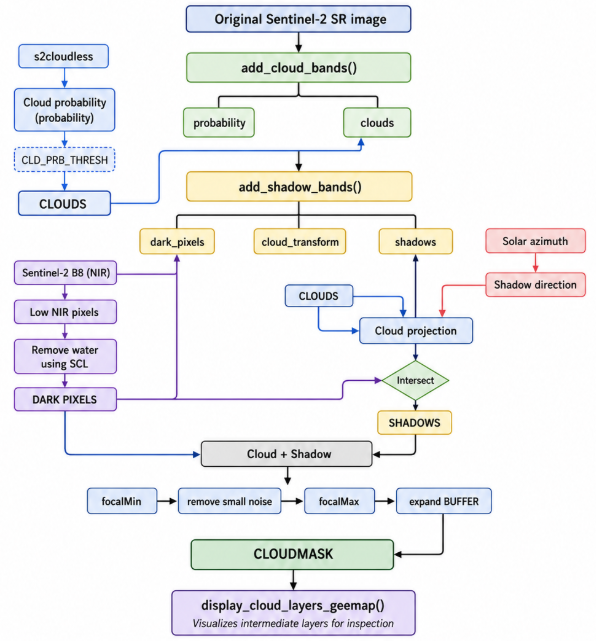

### Display mask component layers

In [27]:
s2_sr_cld_col_eval_disp = s2_sr_cld_col_eval.map(add_cld_shdw_mask)
display_map = display_cloud_layers_geemap(s2_sr_cld_col_eval_disp, AOI)
display_map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

(1) Zoom in to a cloudy region and look at the S2 image, 'clouds' layer, 'dark pixels', and the 'shadows' layers. Write a short paragraph that discusses:

- The performance of each masking element. Are they perfect or getting confused? What is causing the confusion?
- How do the three elements work together to define pixels that are not clear? Show an understanding of both the algorithm you have just applied and the underlying spectral sensing principles.

(10 pts)

(2) Exercise: change the above CLD_PRB_THRESH, NIR_DRK_THRESH, CLD_PRJ_DIST, and BUFFER input variables and rerun the previous cells to see how the results change. Present a figure that compares between the first version you ran and your final version. State the values you have selected and describe the improvements in performance you have managed to achieve in the figure caption.

(10 pts)

## Code for Q2

In [95]:
# Tuned cloud and shadow masking parameters
CLD_PRB_THRESH = 40     #50
NIR_DRK_THRESH = 0.12   #0.15
CLD_PRJ_DIST = 1.5      #1
BUFFER = 70             #50

In [114]:
s2_sr_cld_col_tuned = s2_sr_cld_col_eval.map(add_cld_shdw_mask)
display_map = display_cloud_layers_geemap(s2_sr_cld_col_tuned, AOI)
display_map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

### Create figure for Q2

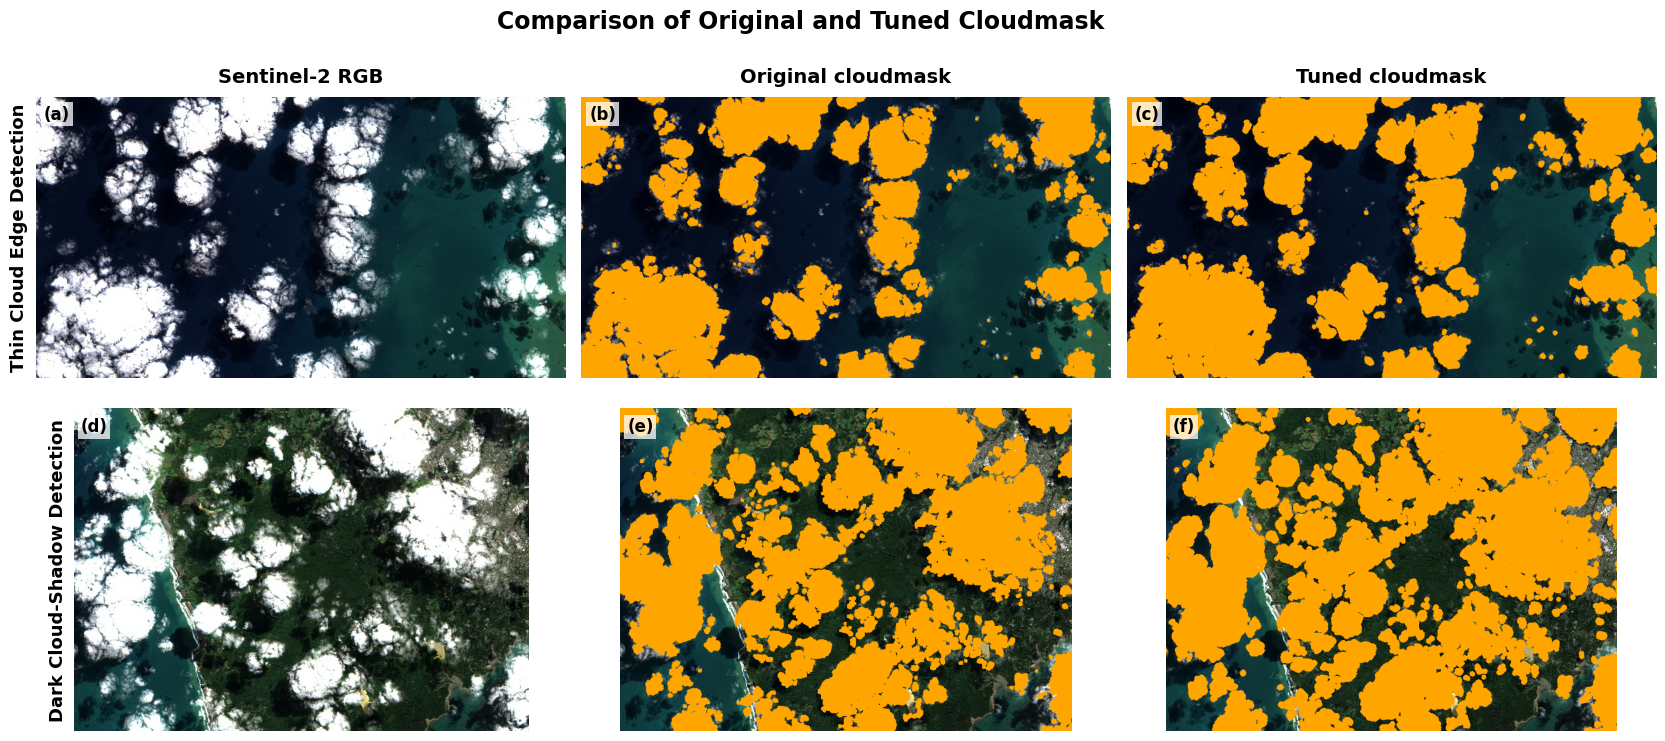

Figure 1. Comparison of original and tuned cloudmask layers. (a) Sentinel-2 RGB reference image for cloud-edge assessment; (b) Cloud-edge masking using the original parameters; (c) Cloud-edge masking using the tuned parameters; (d) Sentinel-2 RGB reference image for cloud-shadow assessment; (e) Shadow masking using the original parameters; and (f) Shadow masking using the tuned parameters. The tuned values were CLD_PRB_THRESH = 40, NIR_DRK_THRESH = 0.12, CLD_PRJ_DIST = 1.5, and BUFFER = 70. Overall improvement was modest and is difficult to distinguish at zoomed out view, but the zoomed-in comparison shows more complete detection of this and less distinct cloud edges and improved coverage of cloud shadows especially over land.


In [125]:
# GitHub raw directory containing the Q2 figure images
BASE_URL = (
    'https://raw.githubusercontent.com/'
    'DannyJung23/SatelliteDataAI-UoA/main/'
    'My-Lab-Notebooks/Lab3-Assets/'
)

filenames = [
    'q2_s2image_cloud.png',
    'q2_original_cloud.png',
    'q2_tuned_cloud.png',
    'q2_s2image_shadow.png',
    'q2_original_shadow.png',
    'q2_tuned_shadow.png'
]

# Download screenshots temporarily and read them as images
images = []
with tempfile.TemporaryDirectory() as tmpdir:

    for filename in filenames:

        local_path = os.path.join(tmpdir, filename)
        urllib.request.urlretrieve(BASE_URL + filename, local_path)
        images.append(mpimg.imread(local_path))

# Create comparison figure
fig, axes = plt.subplots(2, 3, figsize=(18, 7.8))
column_titles = ['Sentinel-2 RGB', 'Original cloudmask', 'Tuned cloudmask']
row_labels = ['Thin Cloud Edge Detection', 'Dark Cloud-Shadow Detection']

# Plot screenshots
for ax, image in zip(axes.flat, images):
    ax.imshow(image)
    ax.axis('off')

# Column titles
for j, title in enumerate(column_titles):
    axes[0, j].set_title(
        title,
        fontsize=14,
        fontweight='bold',
        pad=10
    )

# Row labels
for i, label in enumerate(row_labels):
    axes[i, 0].text(
        -0.015,
        0.5,
        label,
        transform=axes[i, 0].transAxes,
        rotation=90,
        va='center',
        ha='right',
        fontsize=13,
        fontweight='bold'
    )

# Panel labels
panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

for ax, label in zip(axes.flat, panel_labels):
    ax.text(
        0.015,
        0.97,
        label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight='bold',
        va='top',
        ha='left',
        bbox=dict(
            facecolor='white',
            alpha=0.75,
            edgecolor='none',
            pad=2
        )
    )

# Overall figure title
fig.suptitle(
    'Comparison of Original and Tuned Cloudmask',
    fontsize=17,
    fontweight='bold',
    y=0.985
)

# Reduce unnecessary whitespace between screenshots
plt.subplots_adjust(
    left=0.075,
    right=0.975,
    top=0.90,
    bottom=0.06,
    wspace=0.03,
    hspace=0.03
)

caption_q2 = (
    'Figure 1. Comparison of original and tuned cloudmask layers. '
    '(a) Sentinel-2 RGB reference image for cloud-edge assessment; '
    '(b) Cloud-edge masking using the original parameters; '
    '(c) Cloud-edge masking using the tuned parameters; '
    '(d) Sentinel-2 RGB reference image for cloud-shadow assessment; '
    '(e) Shadow masking using the original parameters; '
    'and (f) Shadow masking using the tuned parameters. '
    'The tuned values were CLD_PRB_THRESH = 40, NIR_DRK_THRESH = 0.12, CLD_PRJ_DIST = 1.5, and BUFFER = 70. '
    'Overall improvement was modest and is difficult to distinguish at zoomed out view, '
    'but the zoomed-in comparison shows more complete detection of this '
    'and less distinct cloud edges and improved coverage of cloud shadows especially over land.'
)

plt.show()
print(caption_q2)